# 05 - Modele Foret Aleatoire

## 1. Objectif et protocole

Quantifier la robustesse d'un ensemble d'arbres sans preprocessing et documenter son interpretabilite exploratoire.

Protocole publie dans ce notebook:
- `simple CV` stratifiee pour comparer les variantes non tunees.
- `GridSearchCV` pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `nested CV` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
    verifier_overfit_petit_echantillon,
)
from src.notebook_support import (
    calculer_importance_oob_foret_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_variantes,
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.evaluation.diagnostics_specifiques import oob_vs_n_estimators
from src.plots.specifiques.foret_aleatoire import tracer_oob_vs_n_estimators

In [2]:
MODEL_NAME = "foret_aleatoire"
ctx = creer_notebook_context(MODEL_NAME)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modele", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "simple CV + grid search"),
        ("Confirmation", "nested CV"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modele,Foret aleatoire
1,Famille,ensemble
2,Metrique principale,macro-F1
3,Exploration,simple CV + grid search
4,Confirmation,nested CV


## 2. Signal attendu et design experimental

**Design experimental**
- La foret aleatoire est etudiee sans scaling ni PCA.
- La variante de profondeur restreinte sert de sanity check de complexite, pas de baseline amelioree officielle.
- Les importances publiees dans le notebook doivent venir d'un diagnostic OOB et rester exploratoires.

**Signal attendu**
- Une forte performance sans preprocessing confirmerait la robustesse du modele sur ce tabulaire multiclasses.
- Les importances OOB ne doivent servir qu'a illustrer des tendances descriptives, pas a inferrer une causalite.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `nested CV`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,restricted_depth,simple,{'max_depth': 10}


## 3. Resultats exploratoires non tunes

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les gaps train/validation restent uniquement descriptifs a ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.9788,0.0038,0.9768,0.0047,1.0000,1.0000,0.0212,0.0232,10.4410,cv_n_jobs=1
1,restricted_depth,simple_cv,improved_untuned,0.9636,0.0098,0.9598,0.0110,0.9997,0.9997,0.0361,0.0399,9.5848,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.0212,0.0232
1,restricted_depth,0.0361,0.0399


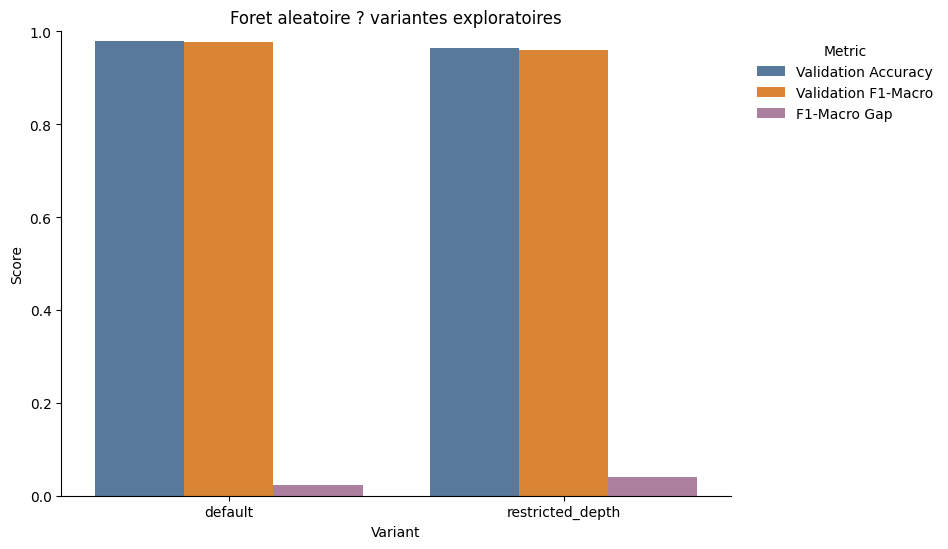

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Resultat confirmatoire tuned

Les cartes du `GridSearchCV` restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `tuned` obtenue en `nested CV`.


In [5]:
tuning = executer_tuning_confirmatoire(ctx)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} ? tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} ? lecture exploratoire du tuning",
            )
            plt.show()


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,tuned,nested_cv,tuned,0.9808,0.0090,0.9789,0.0094,NaN,NaN,NaN,NaN,385.3213,cv_n_jobs=1
1,default,simple_cv,baseline,0.9788,0.0038,0.9768,0.0047,1.0000,1.0000,0.0212,0.0232,10.4410,cv_n_jobs=1
2,restricted_depth,simple_cv,improved_untuned,0.9636,0.0098,0.9598,0.0110,0.9997,0.9997,0.0361,0.0399,9.5848,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,1.0,1.0,0.9848,0.9838,77.1629,0.0355,0.9707
1,2,1.0,1.0,0.9646,0.9623,80.1349,0.0468,0.9711
2,3,1.0,1.0,0.9848,0.9838,88.9336,0.0467,0.9801
3,4,1.0,1.0,0.9848,0.9838,78.7515,0.0266,0.9772
4,5,1.0,1.0,0.9848,0.9805,59.4692,0.0289,0.9743


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators
1,1,0.9820,0.0049,3.8413,None,sqrt,1,400
0,2,0.9797,0.0012,2.5226,None,sqrt,1,200
3,3,0.9778,0.0032,4.2992,None,sqrt,2,400
5,4,0.9757,0.0083,5.0078,20,sqrt,1,400
2,5,0.9756,0.0027,1.6322,None,sqrt,2,200
7,6,0.9737,0.0033,4.6032,20,sqrt,2,400
6,7,0.9724,0.0043,2.6405,20,sqrt,2,200
4,8,0.9701,0.0066,2.4243,20,sqrt,1,200


## 5. Verifications de validite scientifique

Cette section impose le meme contrat minimal dans tous les notebooks:
baseline dummy, test de bruit aleatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))

if MODEL_NAME == "mlp":
    mini_overfit = pd.DataFrame([verifier_overfit_petit_echantillon()])
    display(Markdown("**Sanity check additionnel MLP.** Ce test verifie qu'un reseau dense peut sur-apprendre un micro-echantillon synthetique."))
    display(mini_overfit.round(4))


**Note protocolaire.** Les variantes non tunees restent exploratoires; les figures refittees sur tout le dataset aussi. Les predictions OOF de la variante tuned sont des diagnostics descriptifs confirmatoires, mais seul le score tuned en nested CV sert au classement final inter-modeles.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0101,0.0,0.0002,0.0,0.0101,0.0002,0.001,0.0016,0.024,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0111,0.0093,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des predictions `OOF` de la `nested CV` sont confirmatoires.
Les diagnostics issus d'un refit global ou du `grid search` complet sont explicitement exploratoires.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Quercus_Kewensis,1.0000,0.6,0.7500,10,0.000,0.4,1.000
1,Quercus_Greggii,1.0000,0.8,0.8889,10,0.000,0.2,1.000
2,Arundinaria_Simonii,1.0000,0.9,0.9474,10,0.000,0.1,1.000
3,Callicarpa_Bodinieri,1.0000,0.9,0.9474,10,0.000,0.1,1.000
4,Prunus_X_Shmittii,1.0000,0.9,0.9474,10,0.000,0.1,1.000
5,Pterocarya_Stenoptera,1.0000,0.9,0.9474,10,0.000,0.1,1.000
6,Crataegus_Monogyna,1.0000,0.9,0.9474,10,0.000,0.1,1.000
7,Ilex_Cornuta,1.0000,0.9,0.9474,10,0.000,0.1,1.000
8,Quercus_Shumardii,1.0000,0.9,0.9474,10,0.000,0.1,1.000
9,Quercus_Phillyraeoides,1.0000,0.9,0.9474,10,0.000,0.1,1.000


,classe_vraie,classe_predite,nombre_erreurs
0,Quercus_Kewensis,Quercus_Infectoria_sub,2
1,Arundinaria_Simonii,Eucalyptus_Glaucescens,1
2,Callicarpa_Bodinieri,Sorbus_Aria,1
3,Crataegus_Monogyna,Morus_Nigra,1
4,Ilex_Cornuta,Magnolia_Heptapeta,1
5,Populus_Adenopoda,Quercus_Ilex,1
6,Prunus_X_Shmittii,Alnus_Sieboldiana,1
7,Pterocarya_Stenoptera,Alnus_Cordata,1
8,Quercus_Greggii,Populus_Nigra,1
9,Quercus_Greggii,Tilia_Platyphyllos,1


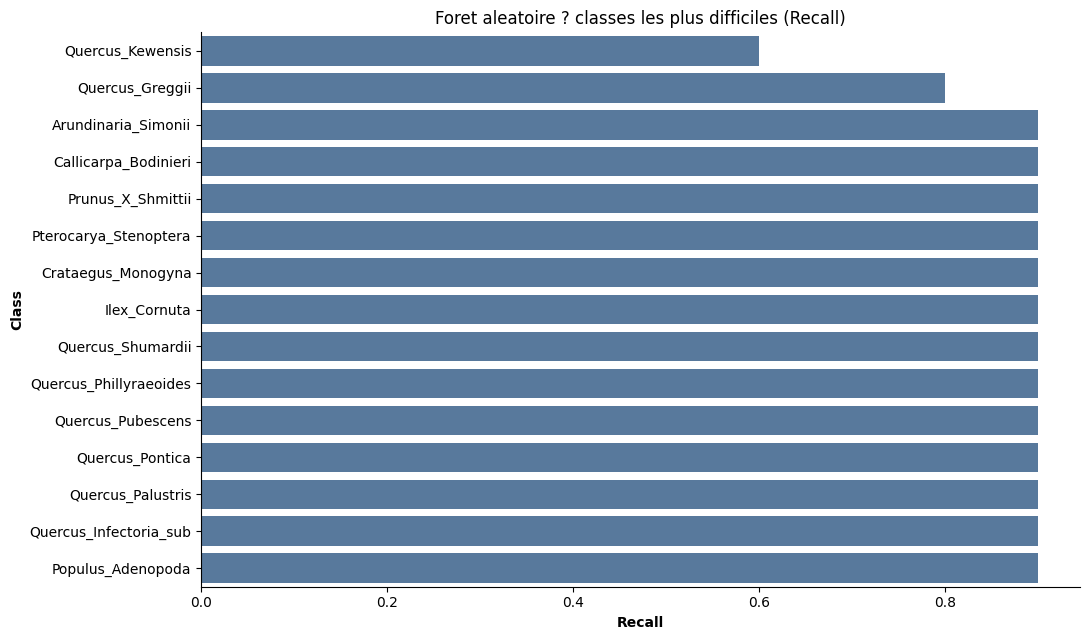

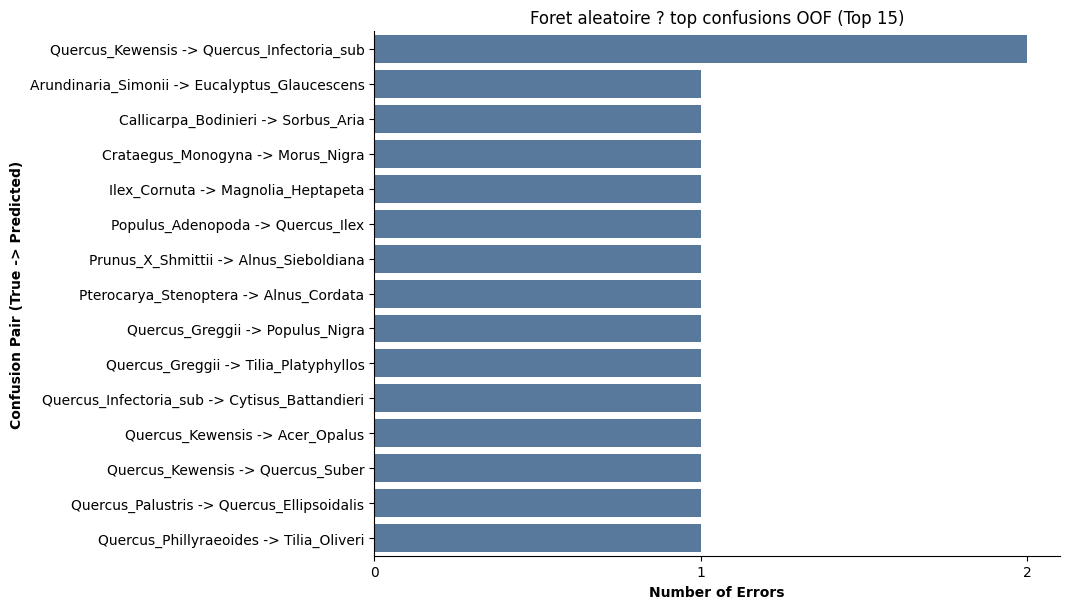

,top_1_accuracy,top_5_accuracy,confiance_moyenne,confiance_erreurs,brier_multiclasse
0,0.9808,1.0,0.4856,0.1802,0.3087


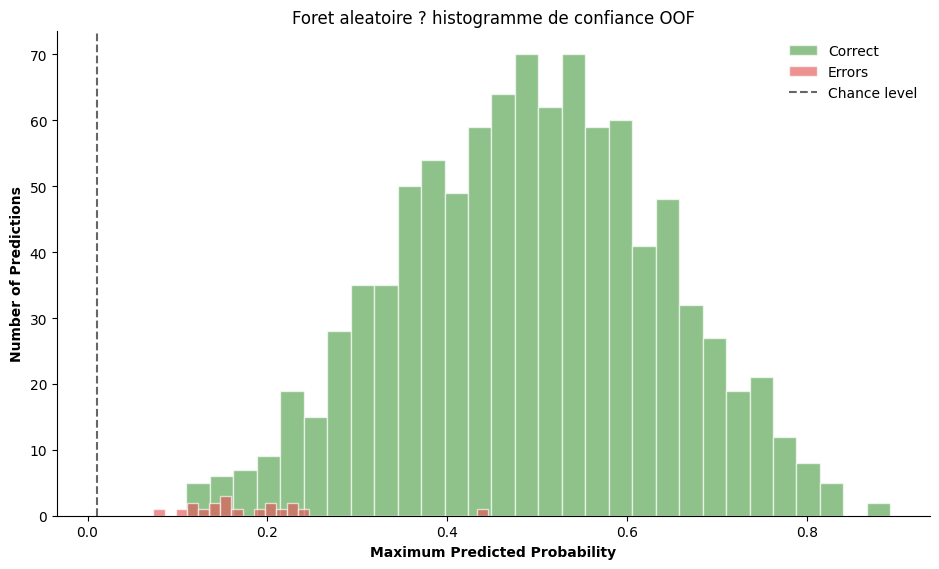

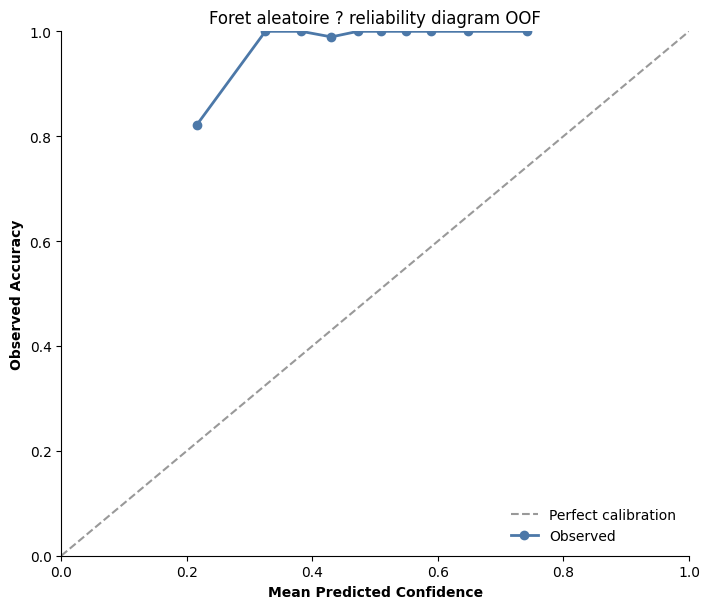

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions OOF",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance OOF",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? reliability diagram OOF",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour `tuned`, les predictions proviennent des artefacts `OOF` de la `nested CV` ;
- pour les variantes non tunees, les predictions sont reconstruites en `simple CV` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.9768,0.9788,0.0232,Populus_Adenopoda -> Quercus_Ilex,2
1,restricted_depth,improved_untuned,0.9598,0.9636,0.0399,Eucalyptus_Glaucescens -> Eucalyptus_Neglecta,2
2,tuned,tuned,0.9789,0.9808,NaN,Quercus_Kewensis -> Quercus_Infectoria_sub,2


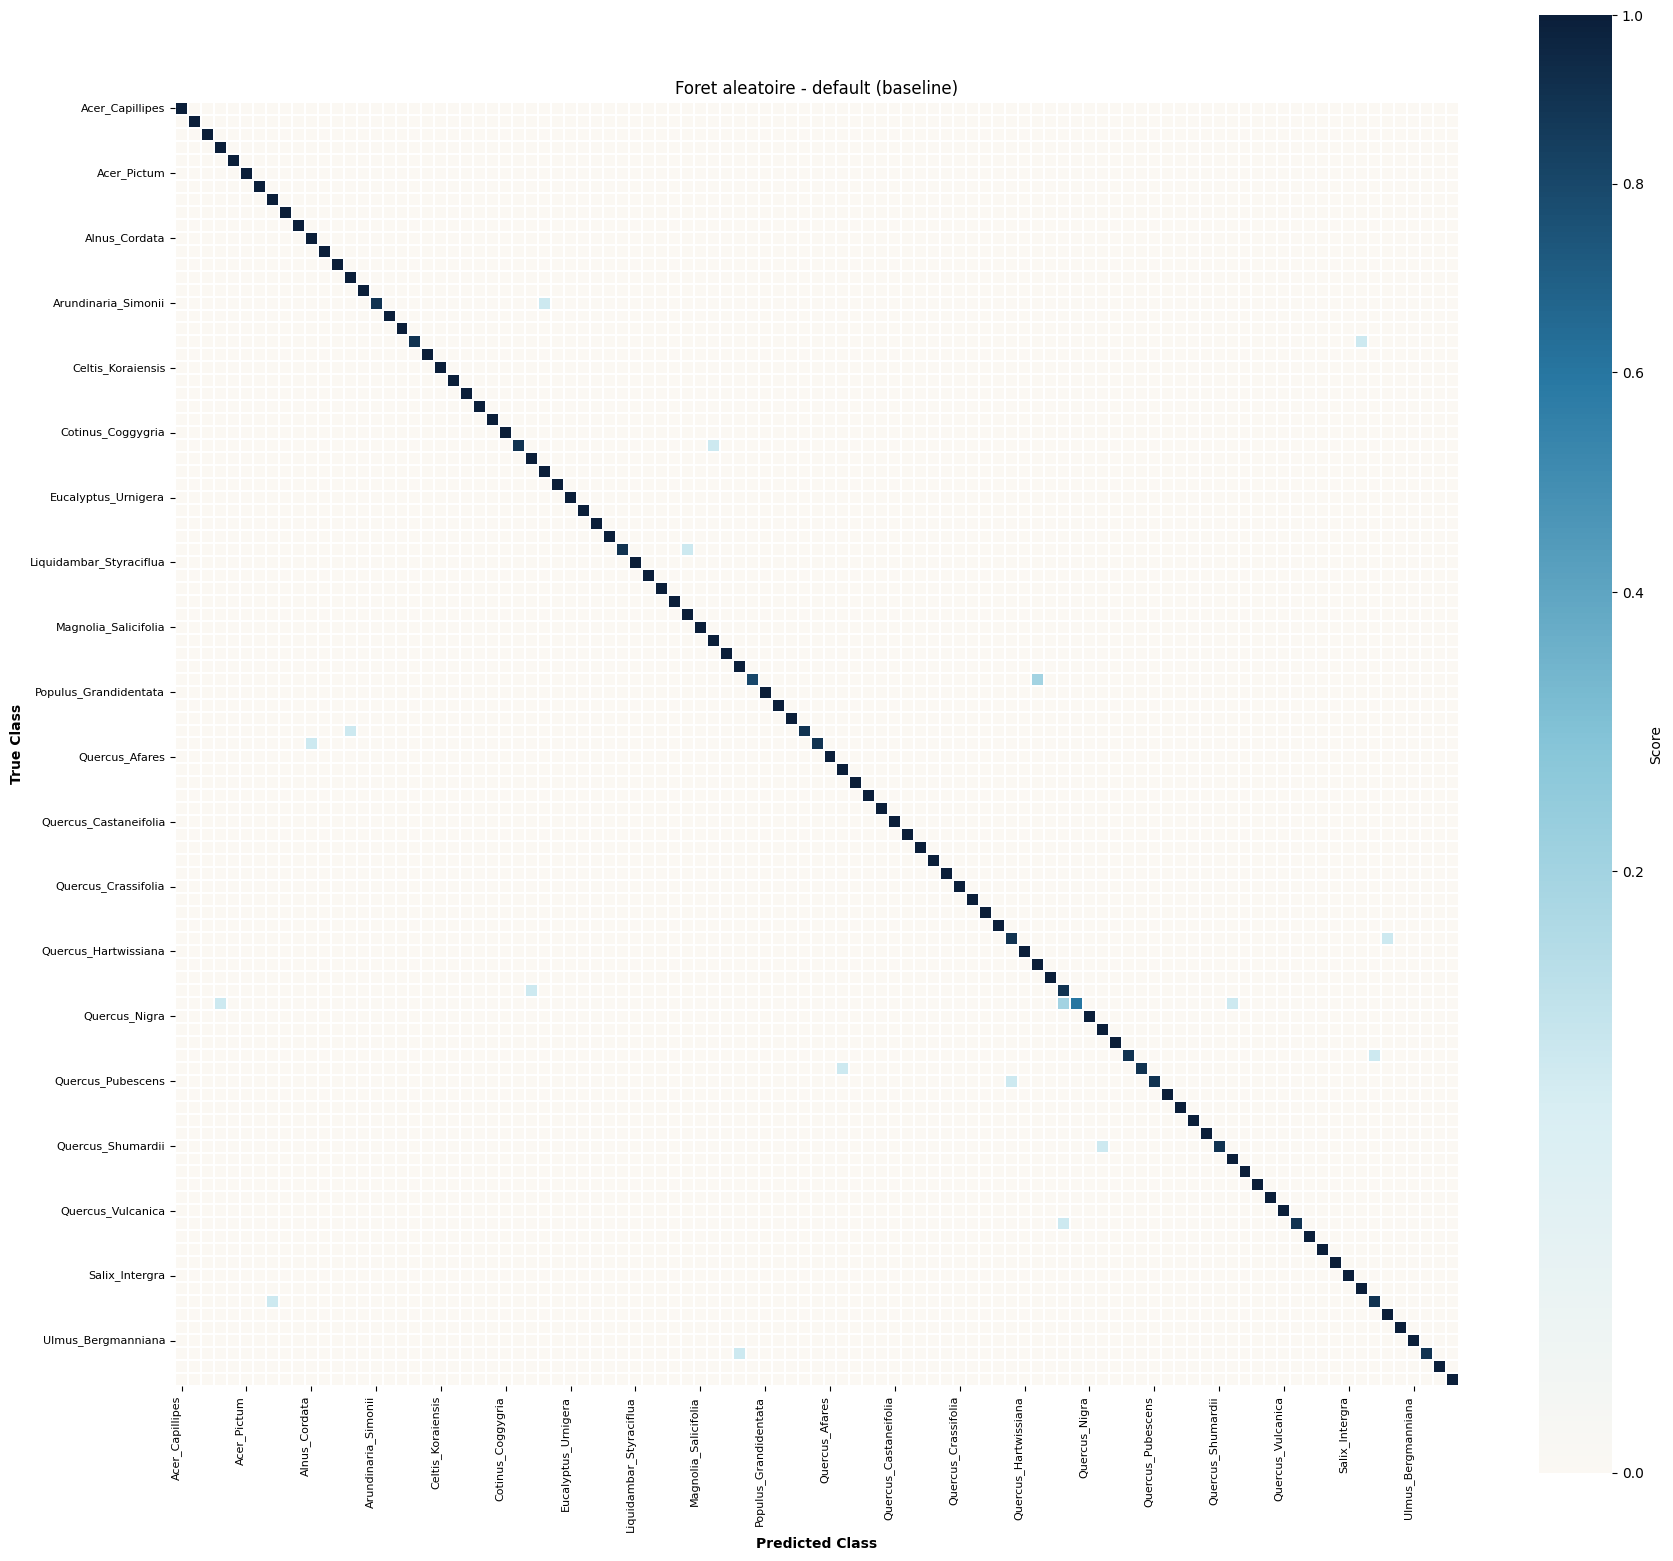

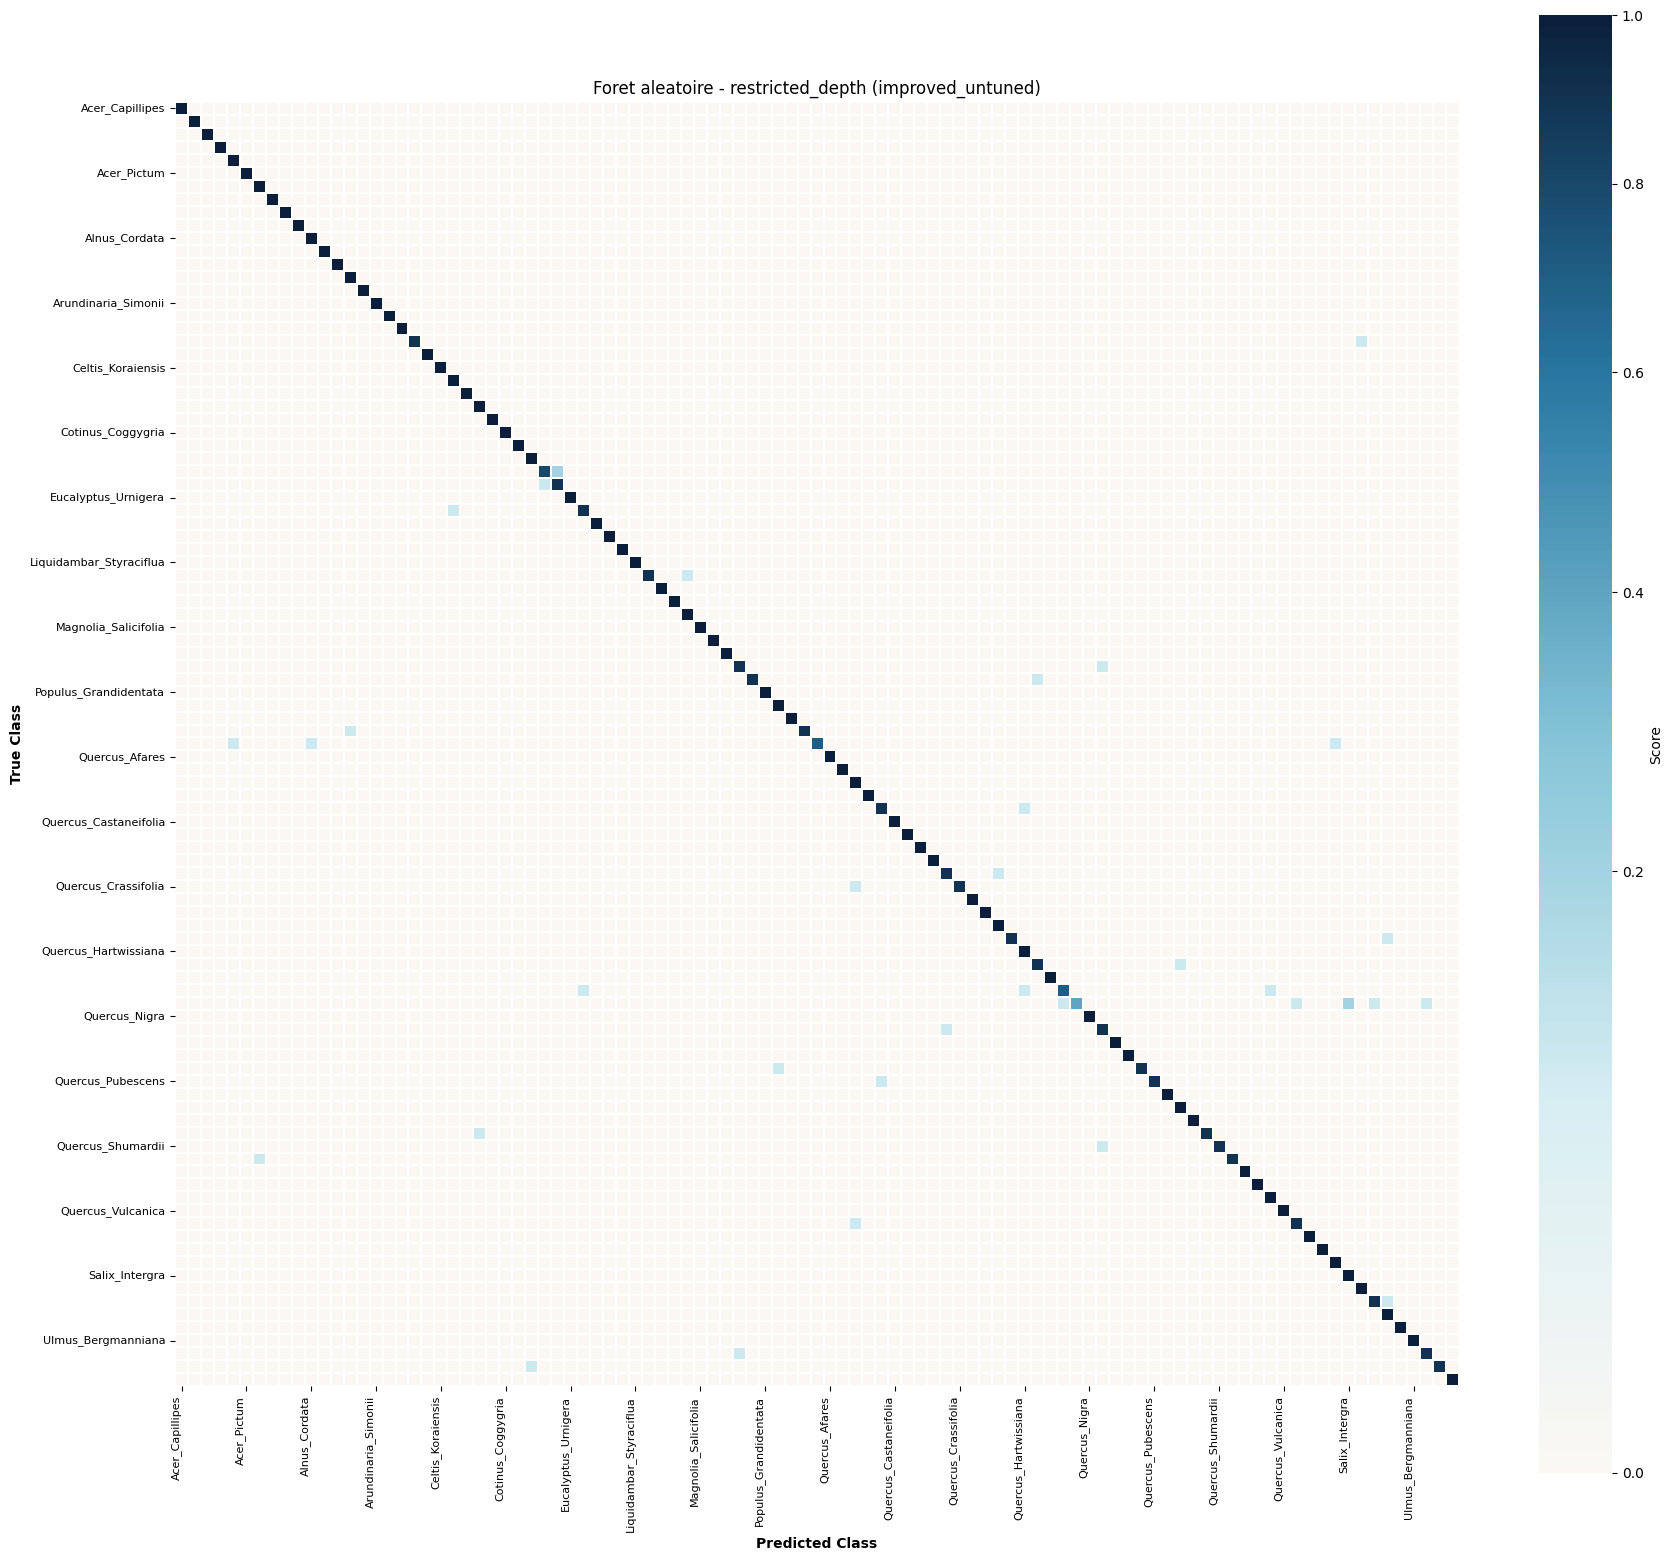

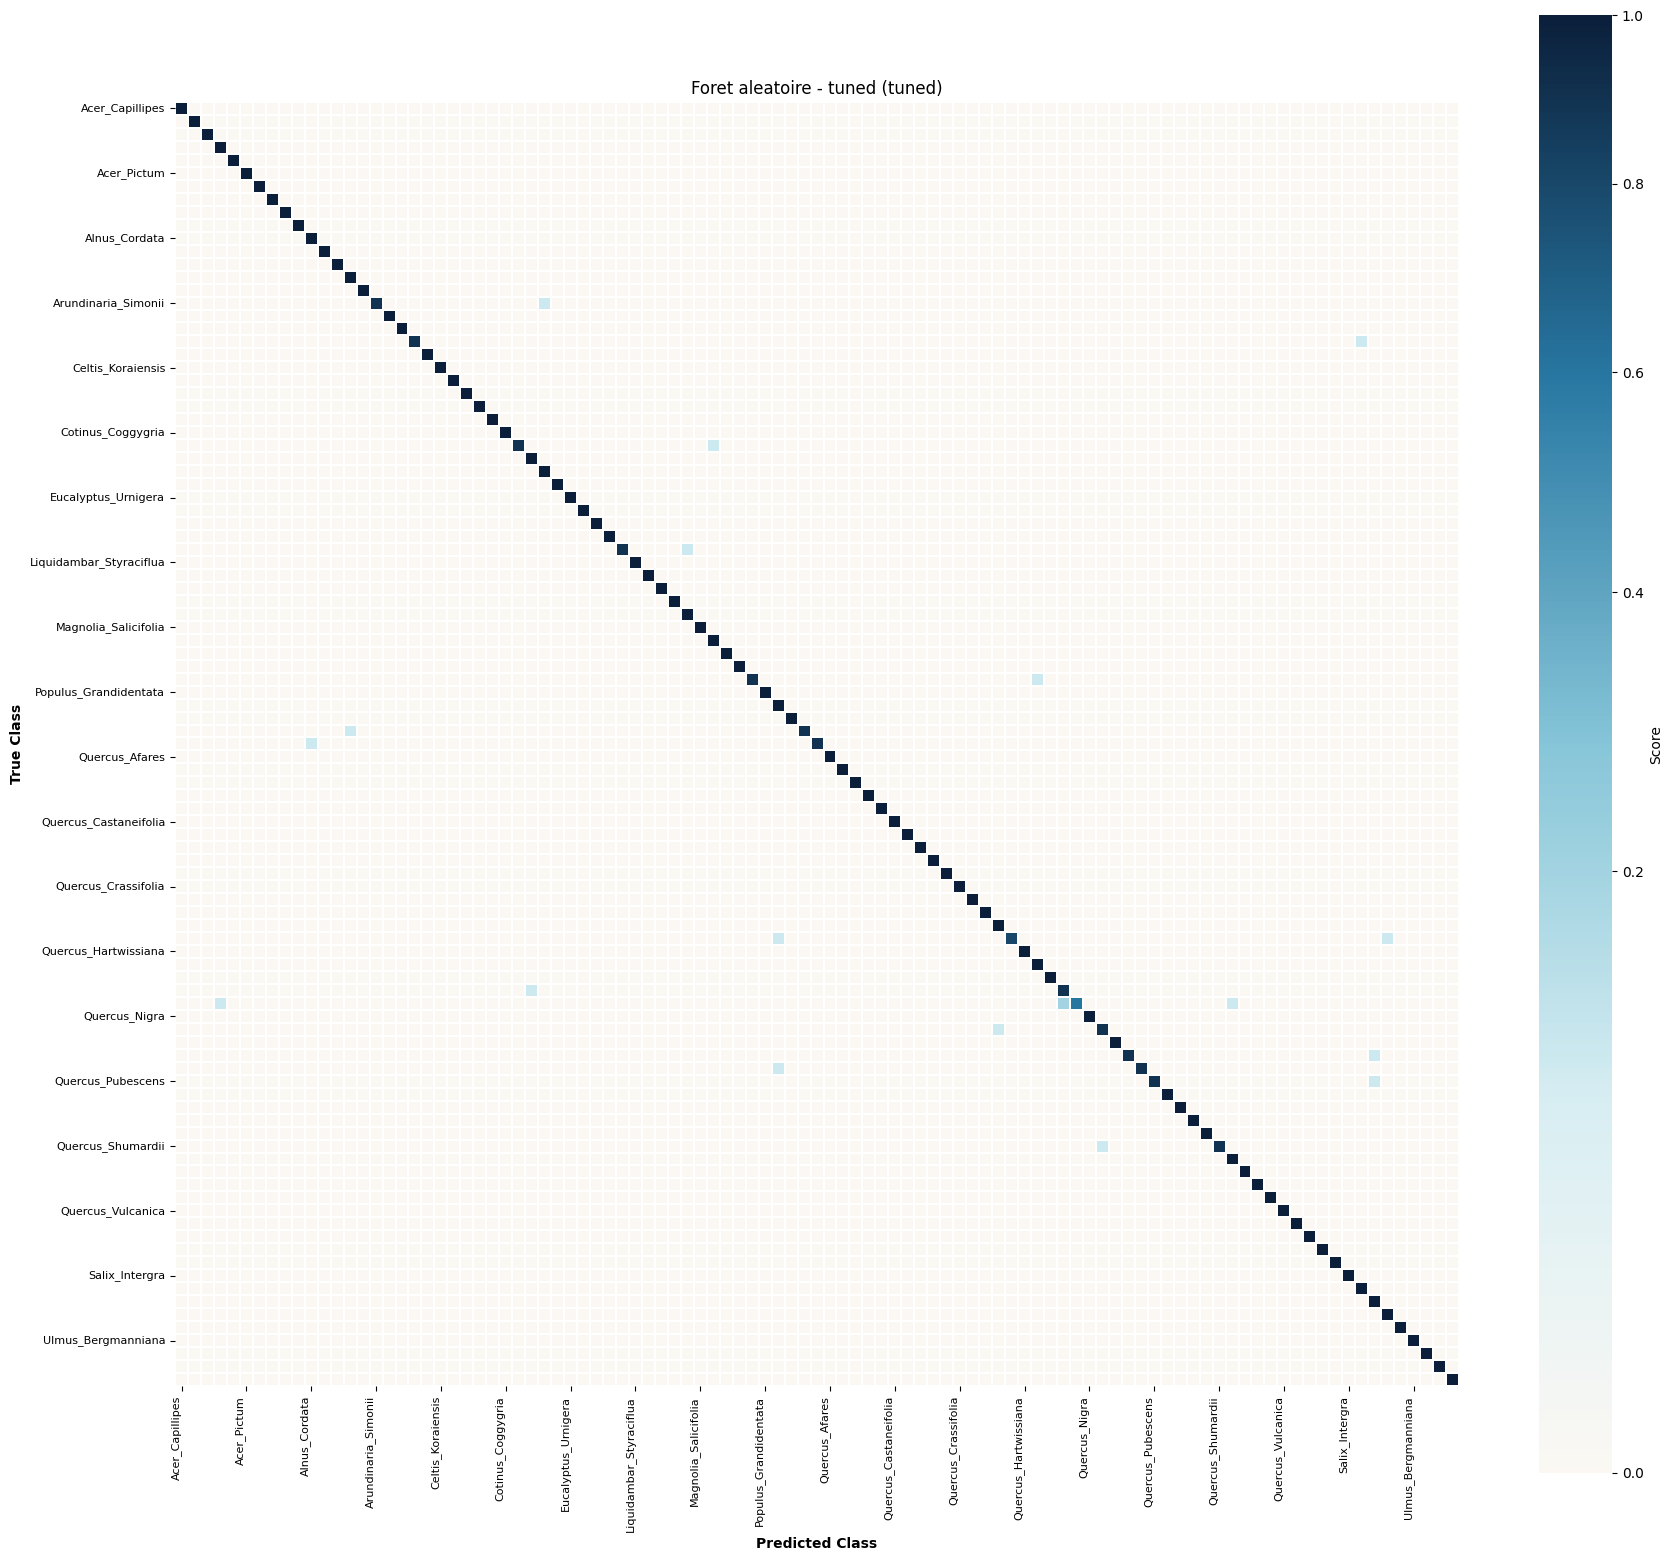

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


_Diagnostic exploratoire specifique._ Les importances ci-dessous proviennent d'une lecture OOB du meilleur estimateur exploratoire. Elles servent a illustrer des tendances descriptives plus proches de la generalisation que le refit in-sample, sans devenir pour autant un resultat confirmatoire.


In [9]:
importance = calculer_importance_oob_foret_exploratoire(
    tuning["grid"].best_estimator_,
    X,
    y,
    n_repeats=5,
)
display(importance.head(20).round(4))


,feature,importance_mean,importance_std
0,shape50,0.0242,0.0498
1,shape48,0.0236,0.0471
2,shape49,0.0224,0.0418
3,shape16,0.0216,0.0424
4,margin31,0.0214,0.0424
5,shape15,0.0190,0.0377
6,shape47,0.0182,0.0414
7,margin2,0.0179,0.0307
8,shape17,0.0179,0.0337
9,shape18,0.0170,0.0338


### Convergence OOB — diagnostic exploratoire

Score OOB (out-of-bag) en fonction du nombre d'arbres, refitte sur le jeu complet.
Ce diagnostic illustre la convergence de l'ensemble — il ne remplace pas l'evaluation par nested CV.

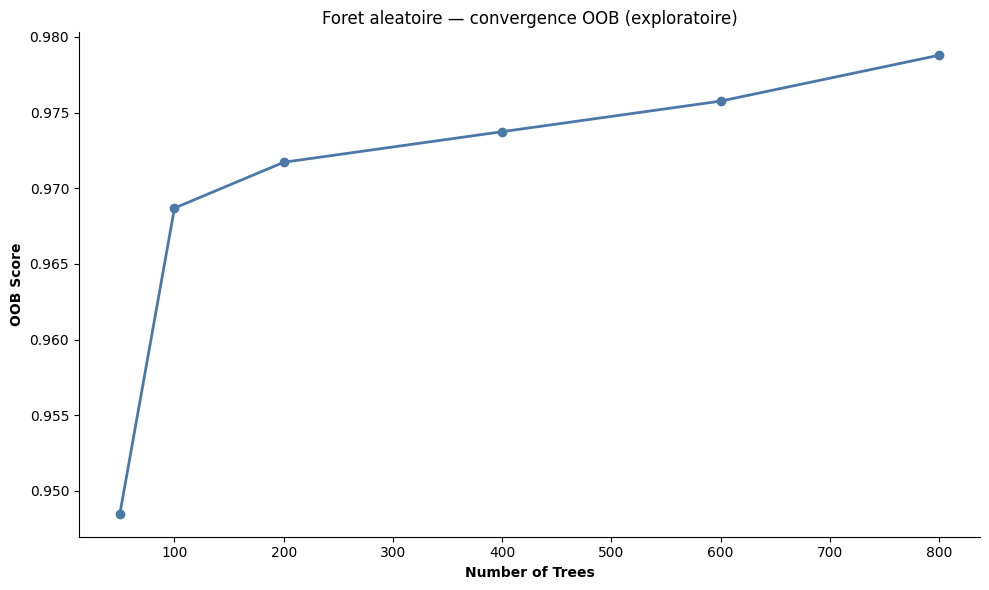

,n_estimators,oob_score
0,50,0.9485
1,100,0.9687
2,200,0.9717
3,400,0.9737
4,600,0.9758
5,800,0.9788


In [10]:
from src.models.pipelines import creer_estimateur

oob_data = oob_vs_n_estimators(creer_estimateur("foret_aleatoire"), X, y)
tracer_oob_vs_n_estimators(
    oob_data,
    titre=f"{definition['nom_affiche']} — convergence OOB (exploratoire)",
)
plt.show()
display(oob_data.round(4))

## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [11]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
default_row = untuned_table.loc[untuned_table["variante"] == "default"].iloc[0]
lignes = [
    f"- Meilleure variante non tunee: `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire `tuned` en nested CV: F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

if "scaled_only" in untuned_table["variante"].values:
    scaled_row = untuned_table.loc[untuned_table["variante"] == "scaled_only"].iloc[0]
    delta_scaling = scaled_row["val_f1_macro_mean"] - default_row["val_f1_macro_mean"]
    lignes.append(
        f"- Effet du scaling sur l'exploration: delta F1-macro = `{delta_scaling:+.4f}` entre `default` et `scaled_only`."
    )

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- Le tuning confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport a la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La nested CV donne une estimation plus conservative que l'exploration simple CV (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunee: `default` avec F1-macro = `0.9768`.
- Estimation confirmatoire `tuned` en nested CV: F1-macro = `0.9789` et accuracy = `0.9808`.
- Le tuning ne change pas materiellement la lecture scientifique par rapport a la meilleure variante exploratoire.